# MNIST CNN Tutorial

This notebook is designed to explain not just how to train a CNN on MNIST, but what is happening inside the model as it learns.

By the end you should be able to:
- compute one convolution response by hand from an image patch and a filter
- explain why deeper convolution layers have many channels and what those channels mean
- track tensor shapes and receptive field growth through the network
- describe how logits become probabilities and how one gradient update changes a weight
- interpret the filters, feature maps, and mistakes of a trained CNN
- distinguish underfitting from overfitting using train/validation curves and model capacity


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(0)
torch.set_printoptions(precision=3, sci_mode=False)


## What Makes A CNN Different?

A fully connected layer assigns a different weight to every pixel position. A convolution layer instead learns a small filter and reuses it everywhere.

For one output location, the calculation is always the same:
1. extract a local patch from the image
2. multiply the patch and filter elementwise
3. sum the products and add a bias
4. optionally pass the result through a nonlinearity such as ReLU

That gives CNNs two strong biases for vision:
- local pattern detection: early filters learn edges, strokes, and corners
- weight sharing: the same filter is reused across the whole image, so the model can detect the same pattern in different positions

The next cell shows both the full response map and one hand-worked output value.


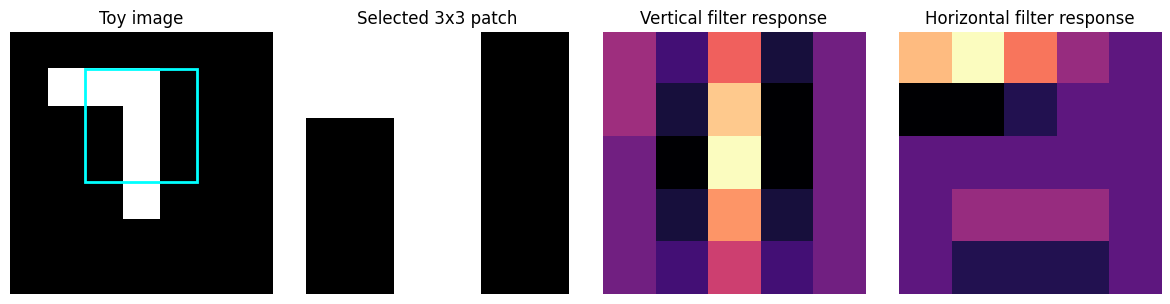

Selected patch:
 tensor([[1., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])
Vertical filter:
 tensor([[-1.,  2., -1.],
        [-1.,  2., -1.],
        [-1.,  2., -1.]])
Elementwise product:
 tensor([[-1.,  2., -0.],
        [-0.,  2., -0.],
        [-0.,  2., -0.]])
Manual weighted sum: 5.0
After adding bias 0.5: 5.5
After ReLU: 5.5
PyTorch value at output location (1, 2): 5.5
Output size formula: floor((7 - 3 + 2*0) / 1) + 1 = 5


In [2]:
toy_image = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
    ],
    dtype=torch.float32,
).view(1, 1, 7, 7)

vertical_filter = torch.tensor(
    [
        [-1.0, 2.0, -1.0],
        [-1.0, 2.0, -1.0],
        [-1.0, 2.0, -1.0],
    ]
).view(1, 1, 3, 3)

horizontal_filter = torch.tensor(
    [
        [-1.0, -1.0, -1.0],
        [2.0, 2.0, 2.0],
        [-1.0, -1.0, -1.0],
    ]
).view(1, 1, 3, 3)

vertical_bias = torch.tensor([0.5])
vertical_response = F.conv2d(toy_image, vertical_filter, bias=vertical_bias)
horizontal_response = F.conv2d(toy_image, horizontal_filter)

manual_row, manual_col = 1, 2
manual_patch = toy_image[0, 0, manual_row : manual_row + 3, manual_col : manual_col + 3]
manual_product = manual_patch * vertical_filter[0, 0]
manual_sum = manual_product.sum().item()
manual_pre_activation = manual_sum + vertical_bias.item()
manual_post_relu = max(manual_pre_activation, 0.0)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(toy_image.squeeze(), cmap="gray")
axes[0].add_patch(
    Rectangle(
        (manual_col - 0.5, manual_row - 0.5),
        3,
        3,
        fill=False,
        edgecolor="cyan",
        linewidth=2,
    )
)
axes[0].set_title("Toy image")
axes[1].imshow(manual_patch, cmap="gray")
axes[1].set_title("Selected 3x3 patch")
axes[2].imshow(vertical_response.squeeze(), cmap="magma")
axes[2].set_title("Vertical filter response")
axes[3].imshow(horizontal_response.squeeze(), cmap="magma")
axes[3].set_title("Horizontal filter response")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Selected patch:\n", manual_patch)
print("Vertical filter:\n", vertical_filter.squeeze())
print("Elementwise product:\n", manual_product)
print("Manual weighted sum:", f"{manual_sum:.1f}")
print("After adding bias 0.5:", f"{manual_pre_activation:.1f}")
print("After ReLU:", f"{manual_post_relu:.1f}")
print(
    "PyTorch value at output location (1, 2):",
    f"{vertical_response[0, 0, manual_row, manual_col].item():.1f}",
)
print(
    "Output size formula: floor((7 - 3 + 2*0) / 1) + 1 =",
    vertical_response.shape[-1],
)


## The MNIST CNN

The network below uses two convolution blocks followed by two fully connected layers.

Read the convolution weight shapes carefully:
- `conv1` has weights of shape `(32, 1, 3, 3)`: 32 learned filters, each looking at the single grayscale input channel
- `conv2` has weights of shape `(64, 32, 3, 3)`: 64 learned filters, and each one combines all 32 channels coming from `conv1`
- `ReLU` keeps positive evidence and discards negative responses
- `max_pool2d` reduces spatial size while preserving the strongest activations
- `dropout` randomly removes activations during training and turns off during evaluation
- `fc1` mixes the extracted visual features, and `fc2` returns logits: raw class scores for digits `0` through `9`


In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward_features(self, x):
        activations = {}

        x = self.conv1(x)          # 1x28x28 -> 32x26x26
        activations["conv1"] = x
        x = F.relu(x)
        activations["relu1"] = x

        x = self.conv2(x)          # 32x26x26 -> 64x24x24
        activations["conv2"] = x
        x = F.relu(x)
        activations["relu2"] = x

        x = F.max_pool2d(x, 2)     # 64x24x24 -> 64x12x12
        activations["pool"] = x
        x = self.dropout1(x)
        activations["dropout1"] = x

        x = torch.flatten(x, 1)    # 64 * 12 * 12 = 9216 features
        activations["flatten"] = x
        x = self.fc1(x)
        activations["fc1"] = x
        x = F.relu(x)
        activations["relu3"] = x
        x = self.dropout2(x)
        activations["dropout2"] = x

        logits = self.fc2(x)
        activations["logits"] = logits
        return logits, activations

    def forward(self, x):
        logits, _ = self.forward_features(x)
        return logits


## Shape Walkthrough

The `9216` in `fc1` is not a magic number. For a convolution layer, each spatial dimension changes according to:

`output_size = floor((input_size - kernel_size + 2 * padding) / stride) + 1`

With `kernel_size=3`, `stride=1`, and `padding=0`, the spatial sizes become:

`28 -> 26 -> 24 -> 12`

The parameter count also follows a formula:
- convolution: `out_channels * (in_channels * kernel_size * kernel_size + 1)`
- linear layer: `out_features * (in_features + 1)`

The next cells trace a batch through the model, show the actual weight tensor shapes, and track how the receptive field grows.


In [4]:
def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def conv_output_size(size, kernel_size, stride=1, padding=0):
    return (size - kernel_size + 2 * padding) // stride + 1


def conv_parameter_count(in_channels, out_channels, kernel_size, bias=True):
    return out_channels * (in_channels * kernel_size * kernel_size + int(bias))


def linear_parameter_count(in_features, out_features, bias=True):
    return out_features * (in_features + int(bias))


def receptive_field_rows(layers):
    rows = []
    receptive_field = 1
    jump = 1
    for name, kernel_size, stride in layers:
        receptive_field = receptive_field + (kernel_size - 1) * jump
        jump = jump * stride
        rows.append((name, kernel_size, stride, receptive_field, jump))
    return rows


shape_model = Net()
x = torch.randn(4, 1, 28, 28)

with torch.no_grad():
    logits, activations = shape_model.forward_features(x)

rows = [
    ("input", tuple(x.shape), 0),
    ("conv1", tuple(activations["conv1"].shape), count_parameters(shape_model.conv1)),
    ("relu1", tuple(activations["relu1"].shape), 0),
    ("conv2", tuple(activations["conv2"].shape), count_parameters(shape_model.conv2)),
    ("relu2", tuple(activations["relu2"].shape), 0),
    ("max_pool", tuple(activations["pool"].shape), 0),
    ("dropout1", tuple(activations["dropout1"].shape), 0),
    ("flatten", tuple(activations["flatten"].shape), 0),
    ("fc1", tuple(activations["fc1"].shape), count_parameters(shape_model.fc1)),
    ("relu3", tuple(activations["relu3"].shape), 0),
    ("dropout2", tuple(activations["dropout2"].shape), 0),
    ("logits", tuple(logits.shape), count_parameters(shape_model.fc2)),
]

print(f'{"layer":<12} {"output shape":<20} {"trainable params"}')
print("-" * 54)
for name, shape, params in rows:
    print(f'{name:<12} {str(shape):<20} {params}')
print("-" * 54)
print("Total trainable parameters:", count_parameters(shape_model))

print("\nWeight tensor shapes:")
print("conv1 weight shape:", tuple(shape_model.conv1.weight.shape))
print("conv2 weight shape:", tuple(shape_model.conv2.weight.shape))

print("\nFormula checks:")
print("conv1 params:", conv_parameter_count(1, 32, 3), "=", count_parameters(shape_model.conv1))
print("conv2 params:", conv_parameter_count(32, 64, 3), "=", count_parameters(shape_model.conv2))
print("fc1 params:", linear_parameter_count(9216, 128), "=", count_parameters(shape_model.fc1))
print("fc2 params:", linear_parameter_count(128, 10), "=", count_parameters(shape_model.fc2))

print("\nSpatial size checks:")
print("28 ->", conv_output_size(28, 3), "after conv1")
print("26 ->", conv_output_size(26, 3), "after conv2")
print("24 ->", conv_output_size(24, 2, stride=2), "after max pool")

print("\nReceptive field growth:")
print(f'{"layer":<12} {"kernel":<8} {"stride":<8} {"rf size":<8} {"jump"}')
for name, kernel, stride, rf, jump in receptive_field_rows(
    [("conv1", 3, 1), ("conv2", 3, 1), ("max_pool", 2, 2)]
):
    print(f'{name:<12} {kernel:<8} {stride:<8} {rf:<8} {jump}')
print("\nOne conv2 output value is built from 32 separate 3x3 channel-wise matches plus one bias.")


layer        output shape         trainable params
------------------------------------------------------
input        (4, 1, 28, 28)       0
conv1        (4, 32, 26, 26)      320
relu1        (4, 32, 26, 26)      0
conv2        (4, 64, 24, 24)      18496
relu2        (4, 64, 24, 24)      0
max_pool     (4, 64, 12, 12)      0
dropout1     (4, 64, 12, 12)      0
flatten      (4, 9216)            0
fc1          (4, 128)             1179776
relu3        (4, 128)             0
dropout2     (4, 128)             0
logits       (4, 10)              1290
------------------------------------------------------
Total trainable parameters: 1199882

Weight tensor shapes:
conv1 weight shape: (32, 1, 3, 3)
conv2 weight shape: (64, 32, 3, 3)

Formula checks:
conv1 params: 320 = 320
conv2 params: 18496 = 18496
fc1 params: 1179776 = 1179776
fc2 params: 1290 = 1290

Spatial size checks:
28 -> 26 after conv1
26 -> 24 after conv2
24 -> 12 after max pool

Receptive field growth:
layer        kernel   stride

## One Image Through The Network

A batch dimension can hide the process. The next cell follows a single image-sized tensor through the model and separates three ideas:
- feature maps: stacks of learned responses across channels
- logits: raw class scores before normalization
- probabilities: softmax outputs that sum to `1`


In [5]:
single_image = torch.randn(1, 1, 28, 28)
single_model = Net()
single_model.eval()

with torch.no_grad():
    logits, activations = single_model.forward_features(single_image)
    probabilities = torch.softmax(logits, dim=1)

trace_rows = [
    ("input", tuple(single_image.shape), "1 grayscale image"),
    ("conv1", tuple(activations["conv1"].shape), "32 feature maps"),
    ("relu1", tuple(activations["relu1"].shape), "negative responses clipped to 0"),
    ("conv2", tuple(activations["conv2"].shape), "64 feature maps, each built from all 32 input channels"),
    ("relu2", tuple(activations["relu2"].shape), "nonlinearity keeps positive evidence"),
    ("max_pool", tuple(activations["pool"].shape), "strongest response kept in each 2x2 window"),
    ("flatten", tuple(activations["flatten"].shape), "64 x 12 x 12 becomes one vector"),
    ("fc1", tuple(activations["fc1"].shape), "dense combination of learned features"),
    ("logits", tuple(logits.shape), "10 raw class scores"),
    ("probabilities", tuple(probabilities.shape), "softmax outputs that sum to 1"),
]

print(f'{"stage":<14} {"shape":<20} explanation')
print("-" * 80)
for name, shape, explanation in trace_rows:
    print(f'{name:<14} {str(shape):<20} {explanation}')
print("-" * 80)

top_probs, top_labels = probabilities[0].topk(3)
print("Probabilities sum to:", f"{probabilities.sum().item():.3f}")
print("Top 3 classes for this image-sized tensor:")
for label, prob in zip(top_labels.tolist(), top_probs.tolist()):
    print(f"  class {label}: {prob:.3f}")


stage          shape                explanation
--------------------------------------------------------------------------------
input          (1, 1, 28, 28)       1 grayscale image
conv1          (1, 32, 26, 26)      32 feature maps
relu1          (1, 32, 26, 26)      negative responses clipped to 0
conv2          (1, 64, 24, 24)      64 feature maps, each built from all 32 input channels
relu2          (1, 64, 24, 24)      nonlinearity keeps positive evidence
max_pool       (1, 64, 12, 12)      strongest response kept in each 2x2 window
flatten        (1, 9216)            64 x 12 x 12 becomes one vector
fc1            (1, 128)             dense combination of learned features
logits         (1, 10)              10 raw class scores
probabilities  (1, 10)              softmax outputs that sum to 1
--------------------------------------------------------------------------------
Probabilities sum to: 1.000
Top 3 classes for this image-sized tensor:
  class 9: 0.114
  class 2: 0.107
  cl

## What Happens During Training?

Each training iteration follows the same process:
1. take a batch of images and labels
2. run a forward pass to produce logits for digits `0` through `9`
3. compute `CrossEntropyLoss`, which internally applies `log_softmax` and negative log-likelihood
4. backpropagate gradients with `loss.backward()`, using the chain rule to push error signals back through every layer
5. update the weights with `optimizer.step()`

During `model.train()`, dropout randomly zeros some activations. During `model.eval()`, dropout is turned off so predictions become deterministic.

The next cells define the training utilities and show one fully annotated gradient update before the full training loop.


In [6]:
def get_device(no_accel=False):
    if no_accel:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def build_mnist_loaders(batch_size=64, test_batch_size=1000, data_dir="MNIST_data"):
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    )
    train_dataset = datasets.MNIST(data_dir, train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(data_dir, train=False, download=True, transform=transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, test_loader


def train(model, device, train_loader, optimizer, epoch, log_interval=None):
    model.train()
    total_loss = 0.0
    correct = 0
    seen_examples = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = F.cross_entropy(logits, target)
        loss.backward()
        optimizer.step()

        batch_size = data.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        correct += preds.eq(target).sum().item()
        seen_examples += batch_size

        if log_interval is not None and batch_idx % log_interval == 0:
            print(
                "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100.0 * batch_idx / len(train_loader),
                    loss.item(),
                )
            )

    avg_loss = total_loss / seen_examples
    accuracy = correct / seen_examples
    return avg_loss, accuracy


def test(model, device, test_loader):
    model.eval()
    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            logits = model(data)
            test_loss += F.cross_entropy(logits, target, reduction="sum").item()
            pred = logits.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = correct / len(test_loader.dataset)

    return test_loss, accuracy


def inspect_training_step(model, device, train_loader, lr=0.05):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    images, labels = next(iter(train_loader))
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    logits, activations = model.forward_features(images)
    loss = F.cross_entropy(logits, labels)
    loss.backward()

    conv1_grad_norm = model.conv1.weight.grad.norm().item()
    fc2_grad_norm = model.fc2.weight.grad.norm().item()
    probs = torch.softmax(logits[0], dim=0).detach().cpu()
    top_probs, top_labels = probs.topk(3)
    pred = logits.argmax(dim=1)[0].item()

    weight_before = model.conv1.weight[0, 0, 0, 0].item()
    grad_value = model.conv1.weight.grad[0, 0, 0, 0].item()
    expected_after = weight_before - lr * grad_value

    print("Batch shape:", tuple(images.shape))
    print("Conv1 activation shape:", tuple(activations["relu1"].shape))
    print("Logits shape:", tuple(logits.shape))
    print("Loss before the update:", f"{loss.item():.4f}")
    print("Gradient norm for conv1 weights:", f"{conv1_grad_norm:.4f}")
    print("Gradient norm for fc2 weights:", f"{fc2_grad_norm:.4f}")
    print("First sample true label:", labels[0].item())
    print("First sample predicted label before training:", pred)
    print("First sample probabilities sum to:", f"{probs.sum().item():.3f}")
    print("Top 3 class probabilities for the first sample:")
    for label, prob in zip(top_labels.tolist(), top_probs.tolist()):
        print(f"  class {label}: {prob:.3f}")

    optimizer.step()
    actual_after = model.conv1.weight[0, 0, 0, 0].item()
    print("Tracked conv1 weight before update:", f"{weight_before:.6f}")
    print("Its gradient:", f"{grad_value:.6f}")
    print("Expected SGD update old - lr * grad:", f"{expected_after:.6f}")
    print("Actual value after optimizer.step():", f"{actual_after:.6f}")


def inspect_dropout_behavior(p=0.5):
    dropout = nn.Dropout(p)
    probe = torch.ones(1, 12)

    dropout.train()
    train_out = dropout(probe).squeeze(0)
    dropout.eval()
    eval_out = dropout(probe).squeeze(0)

    print("Dropout demo on a vector of ones:")
    print("train() mode output:", train_out.tolist())
    print("eval() mode output: ", eval_out.tolist())
    print("Nonzero train() values are scaled by:", f"{1 / (1 - p):.1f}")


def fit(model, device, train_loader, test_loader, epochs=3, lr=0.05, gamma=0.7, log_interval=None):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=1, gamma=gamma)
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train(
            model, device, train_loader, optimizer, epoch, log_interval=log_interval
        )
        val_loss, val_accuracy = test(model, device, test_loader)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        print(
            f"Epoch {epoch}/{epochs}: "
            f"train loss {train_loss:.4f}, train acc {train_accuracy:.3f}, "
            f"val loss {val_loss:.4f}, val acc {val_accuracy:.3f}"
        )
        scheduler.step()

    return history


## Inspect One Gradient Update

Before training for multiple epochs, it helps to inspect one batch.

Focus on four things in the output:
- the model returns one logit vector per image, so the output shape is `(batch_size, 10)`
- softmax turns logits into probabilities that sum to `1`
- nonzero gradient norms show that backprop reached both early and late layers
- with plain SGD, you can verify one parameter update exactly with `old_weight - lr * gradient`


In [7]:
device = get_device(no_accel=False)
train_loader, test_loader = build_mnist_loaders(batch_size=128, test_batch_size=1000)

print(f"Using device: {device}")
inspect_training_step(Net().to(device), device, train_loader, lr=0.05)
print()
inspect_dropout_behavior(p=0.5)


Using device: mps


Batch shape: (128, 1, 28, 28)
Conv1 activation shape: (128, 32, 26, 26)
Logits shape: (128, 10)
Loss before the update: 2.2976
Gradient norm for conv1 weights: 0.0435
Gradient norm for fc2 weights: 0.2349
First sample true label: 2
First sample predicted label before training: 7
First sample probabilities sum to: 1.000
Top 3 class probabilities for the first sample:
  class 7: 0.118
  class 3: 0.113
  class 8: 0.109
Tracked conv1 weight before update: 0.091367
Its gradient: -0.002307
Expected SGD update old - lr * grad: 0.091482
Actual value after optimizer.step(): 0.091482

Dropout demo on a vector of ones:
train() mode output: [0.0, 2.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 2.0, 0.0, 2.0, 0.0]
eval() mode output:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Nonzero train() values are scaled by: 2.0


## Train The CNN

Now we run the full training loop. The notebook keeps the model intentionally small and uses plain SGD so the earlier `old_weight - lr * gradient` explanation matches the optimizer that actually trains the network.


In [8]:
model = Net().to(device)
initial_conv1_filters = model.conv1.weight.detach().cpu().clone()
history = fit(
    model,
    device,
    train_loader,
    test_loader,
    epochs=3,
    lr=0.05,
    gamma=0.7,
    log_interval=None,
)


Epoch 1/3: train loss 0.4312, train acc 0.865, val loss 0.1138, val acc 0.967


Epoch 2/3: train loss 0.1501, train acc 0.956, val loss 0.0690, val acc 0.977


Epoch 3/3: train loss 0.1088, train acc 0.967, val loss 0.0546, val acc 0.982


## Underfitting vs Overfitting

A model can fail in two very different ways:
- underfitting: the model is too weak, or training is too limited, so both training and validation performance stay poor
- overfitting: the model fits the training set too specifically, so training performance keeps improving while validation performance stalls or gets worse

The next cell runs three deliberately more extreme experiments, all trained for the same 12 epochs:
- underfit: a linear classifier trained on only 256 examples
- healthy fit: the tutorial CNN on a moderate 4000-example subset
- overfit: a wider CNN without dropout trained on just 32 examples

For this comparison we create held-out validation splits from the training set, so the main MNIST test set can remain the final evaluation set. The split, data order, and model initialization are all seeded so the contrast is reproducible, and the helper uses Adam so each model gets a fair chance within the same epoch budget.


experiment                          train acc    val acc        gap   best val
--------------------------------------------------------------------------------
Underfit: linear classifier on 256 examples      0.812      0.683      0.129      0.683
Healthy fit: tutorial CNN               0.976      0.972      0.005      0.972
Overfit: wide CNN on 32 examples        1.000      0.462      0.538      0.463


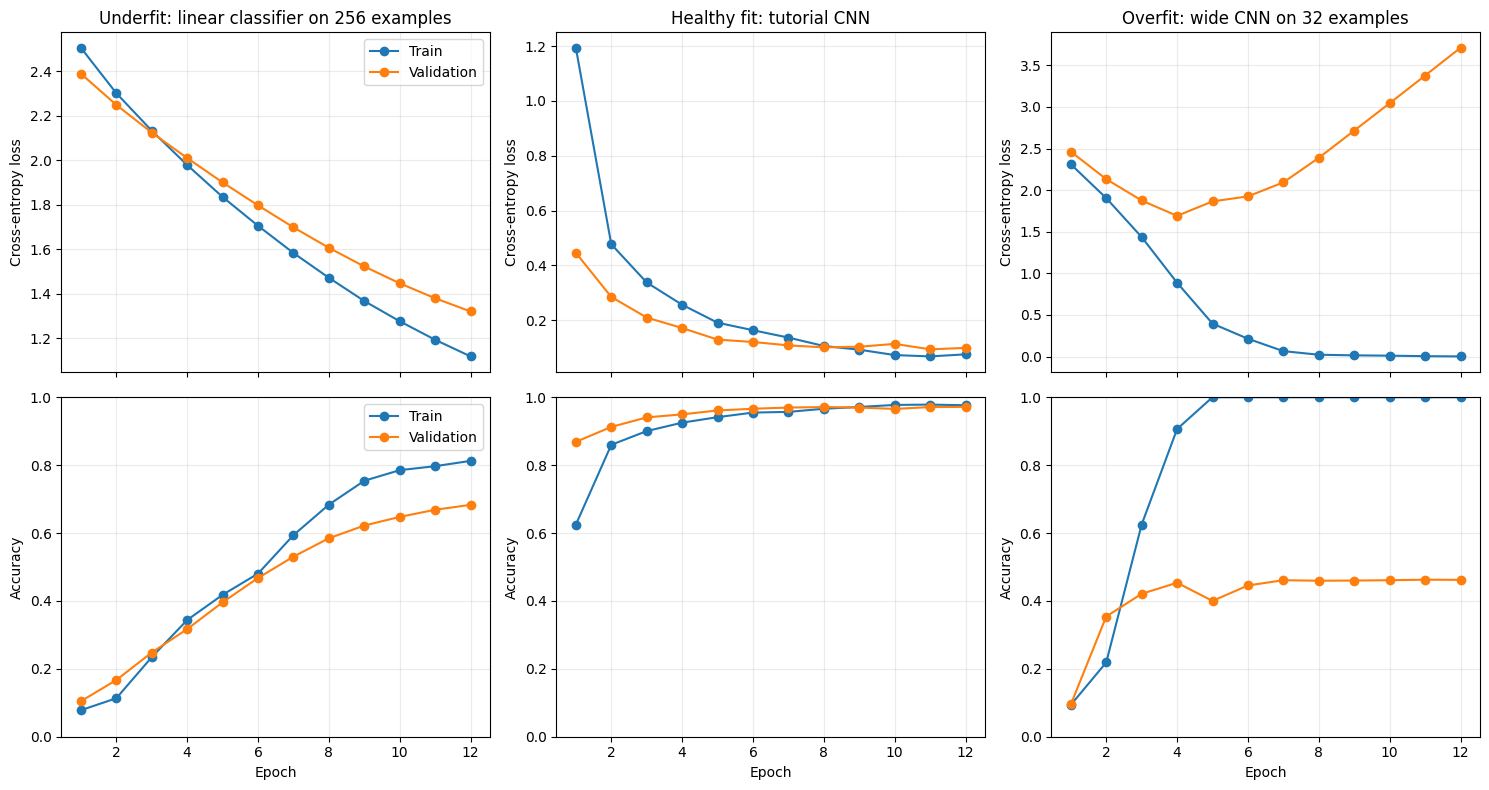

In [9]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(28 * 28, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        return self.fc(x)


class WideNetNoDropout(nn.Module):
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(9216, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def build_train_val_loaders(train_size, val_size, batch_size=128, data_dir="MNIST_data", seed=0):
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    )
    base_train_dataset = datasets.MNIST(
        data_dir, train=True, download=True, transform=transform
    )
    remainder = len(base_train_dataset) - train_size - val_size
    if remainder < 0:
        raise ValueError("train_size + val_size must be <= 60000 for MNIST")

    generator = torch.Generator().manual_seed(seed)
    loader_generator = torch.Generator().manual_seed(seed + 1)
    train_subset, val_subset, _ = random_split(
        base_train_dataset, [train_size, val_size, remainder], generator=generator
    )

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=loader_generator,
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader


def evaluate_silent(model, device, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    seen_examples = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            logits = model(data)
            total_loss += F.cross_entropy(logits, target, reduction="sum").item()
            preds = logits.argmax(dim=1)
            correct += preds.eq(target).sum().item()
            seen_examples += data.size(0)

    return total_loss / seen_examples, correct / seen_examples


def fit_silent(model, device, train_loader, val_loader, epochs=5, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for _ in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        seen_examples = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(data)
            loss = F.cross_entropy(logits, target)
            loss.backward()
            optimizer.step()

            batch_size = data.size(0)
            total_loss += loss.item() * batch_size
            preds = logits.argmax(dim=1)
            correct += preds.eq(target).sum().item()
            seen_examples += batch_size

        train_loss = total_loss / seen_examples
        train_accuracy = correct / seen_examples
        val_loss, val_accuracy = evaluate_silent(model, device, val_loader)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

    return history


small_train_loader, small_val_loader = build_train_val_loaders(
    train_size=256, val_size=2000, batch_size=128, seed=7
)
moderate_train_loader, moderate_val_loader = build_train_val_loaders(
    train_size=4000, val_size=2000, batch_size=128, seed=7
)
tiny_train_loader, tiny_val_loader = build_train_val_loaders(
    train_size=32, val_size=2000, batch_size=32, seed=7
)

experiments = [
    {
        "name": "Underfit: linear classifier on 256 examples",
        "model_fn": LinearClassifier,
        "train_loader": small_train_loader,
        "val_loader": small_val_loader,
        "epochs": 12,
        "lr": 0.0005,
    },
    {
        "name": "Healthy fit: tutorial CNN",
        "model_fn": Net,
        "train_loader": moderate_train_loader,
        "val_loader": moderate_val_loader,
        "epochs": 12,
        "lr": 0.0005,
    },
    {
        "name": "Overfit: wide CNN on 32 examples",
        "model_fn": WideNetNoDropout,
        "model_kwargs": {"hidden_dim": 512},
        "train_loader": tiny_train_loader,
        "val_loader": tiny_val_loader,
        "epochs": 12,
        "lr": 0.001,
    },
]

experiment_results = []
for config in experiments:
    torch.manual_seed(7)
    experiment_model = config["model_fn"](**config.get("model_kwargs", {})).to(device)
    history = fit_silent(
        experiment_model,
        device,
        config["train_loader"],
        config["val_loader"],
        epochs=config["epochs"],
        lr=config["lr"],
    )
    experiment_results.append((config["name"], history))

print(f'{"experiment":<34} {"train acc":>10} {"val acc":>10} {"gap":>10} {"best val":>10}')
print("-" * 80)
for name, history in experiment_results:
    final_train_acc = history["train_accuracy"][-1]
    final_val_acc = history["val_accuracy"][-1]
    best_val_acc = max(history["val_accuracy"])
    gap = final_train_acc - final_val_acc
    print(
        f'{name:<34} {final_train_acc:>10.3f} {final_val_acc:>10.3f} {gap:>10.3f} {best_val_acc:>10.3f}'
    )

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
for col, (name, history) in enumerate(experiment_results):
    epoch_axis = range(1, len(history["train_loss"]) + 1)

    axes[0, col].plot(epoch_axis, history["train_loss"], marker="o", label="Train")
    axes[0, col].plot(epoch_axis, history["val_loss"], marker="o", label="Validation")
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("Cross-entropy loss")
    axes[0, col].grid(alpha=0.25)

    axes[1, col].plot(epoch_axis, history["train_accuracy"], marker="o", label="Train")
    axes[1, col].plot(epoch_axis, history["val_accuracy"], marker="o", label="Validation")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylabel("Accuracy")
    axes[1, col].set_ylim(0.0, 1.0)
    axes[1, col].grid(alpha=0.25)

axes[0, 0].legend()
axes[1, 0].legend()
plt.tight_layout()
plt.show()


Read the curves like this:
- underfitting: training and validation curves stay close, but both remain weak
- healthy fit: both improve to strong performance, and the train/validation gap stays moderate
- overfitting: training can race toward perfect accuracy on the tiny training set while validation improvement slows or reverses, so the gap widens sharply

The key lesson is that generalization is not only about making the training loss small. It is about how well the same learned patterns transfer to new images.


## Evaluate And Interpret The Trained CNN

The final cell connects the abstract layers back to concrete behavior:
- the loss and accuracy curves show whether learning is stable
- the confusion matrix shows which digits the model still mixes up
- the first-layer filters are compared before and after training
- top-activating feature maps show which channels respond most strongly to one digit
- a logits vs probabilities plot shows how the last layer becomes a prediction
- misclassified examples show where the learned features are still not enough


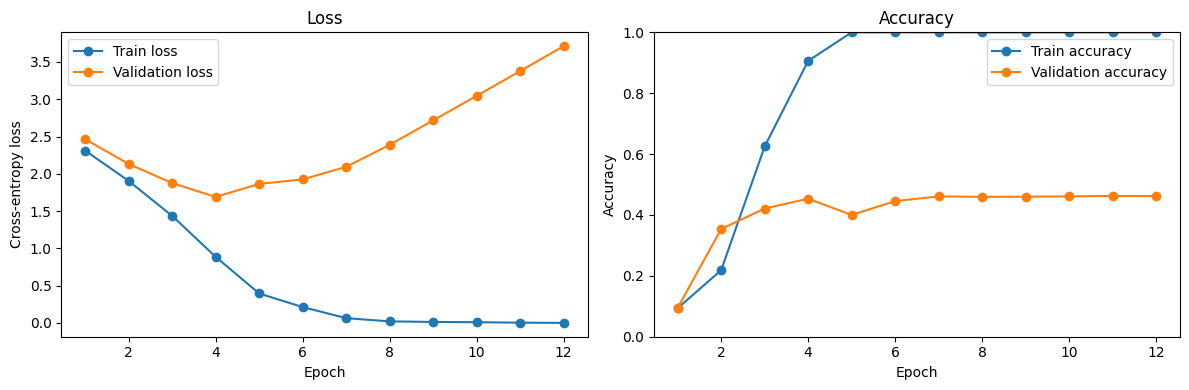

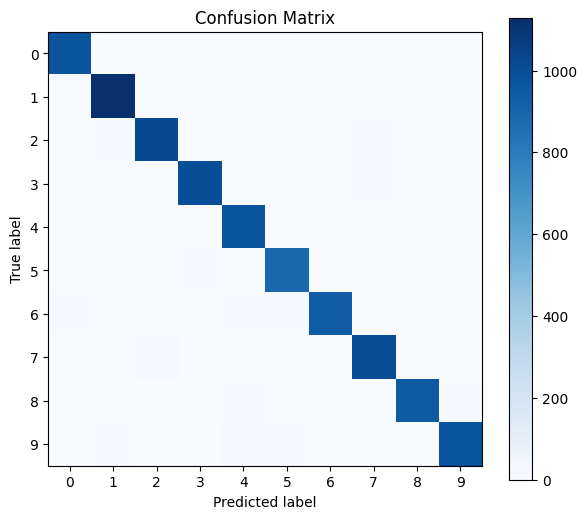

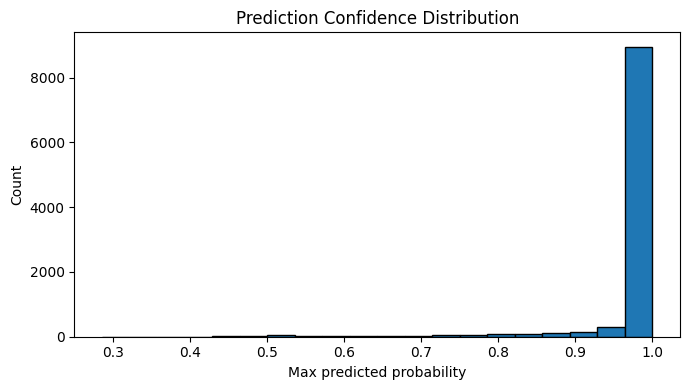

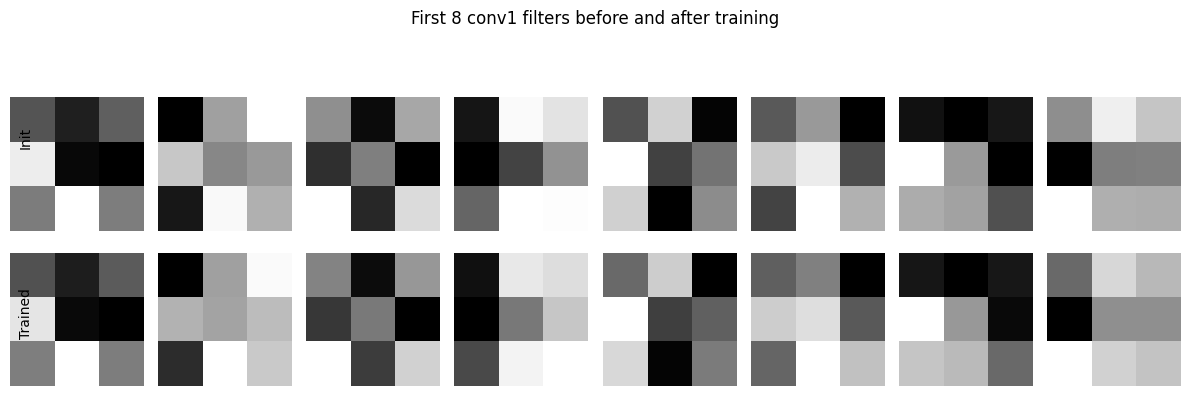

Single-image shape trace:
  input: (1, 1, 28, 28)
  after conv1 + relu: (1, 32, 26, 26)
  after conv2 + relu: (1, 64, 24, 24)
  after max pool: (1, 64, 12, 12)
  after flatten: (1, 9216)
  logits: (1, 10)
  probabilities sum to: 1.000
Top predicted classes for the sample image:
  class 3: 1.000
  class 9: 0.000
  class 5: 0.000


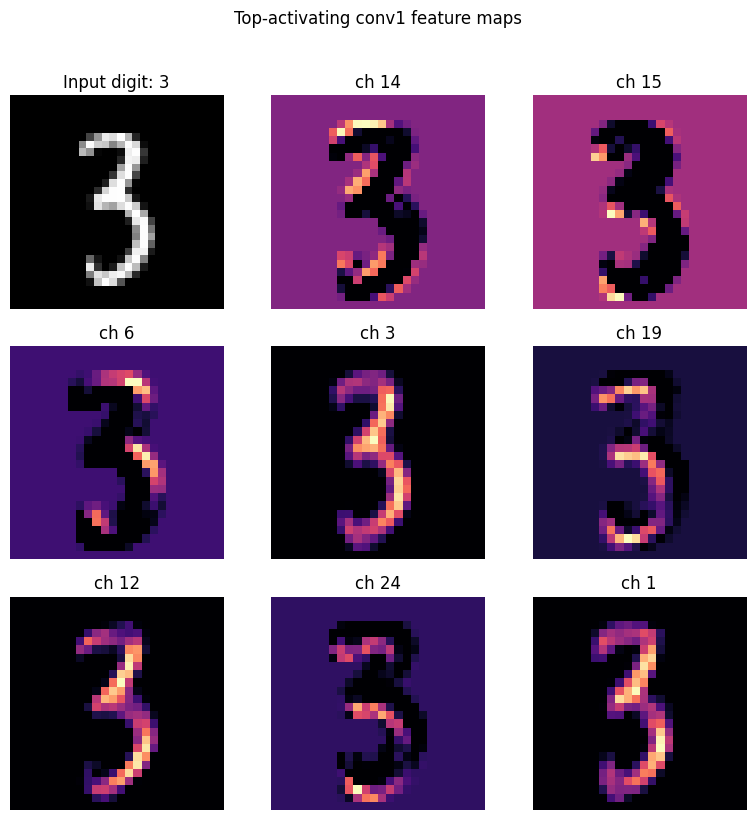

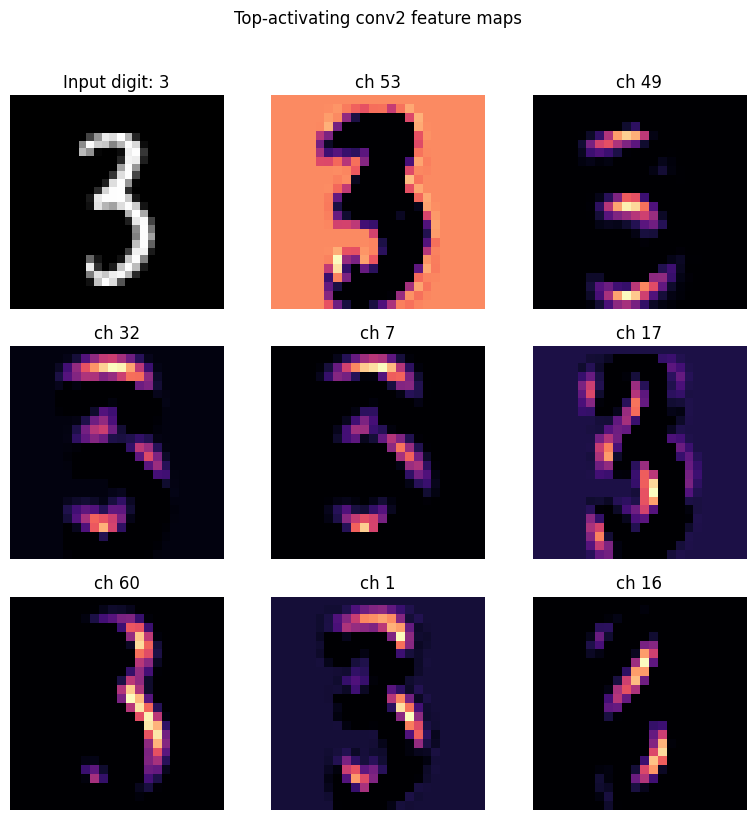

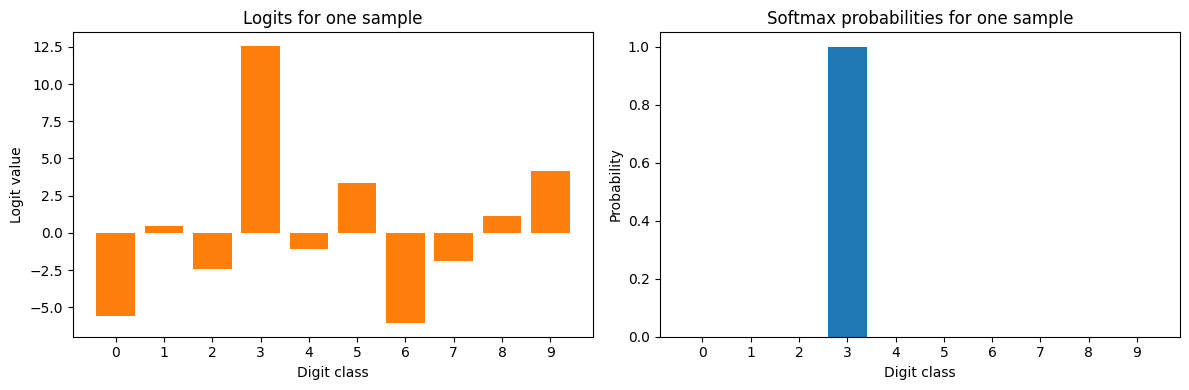

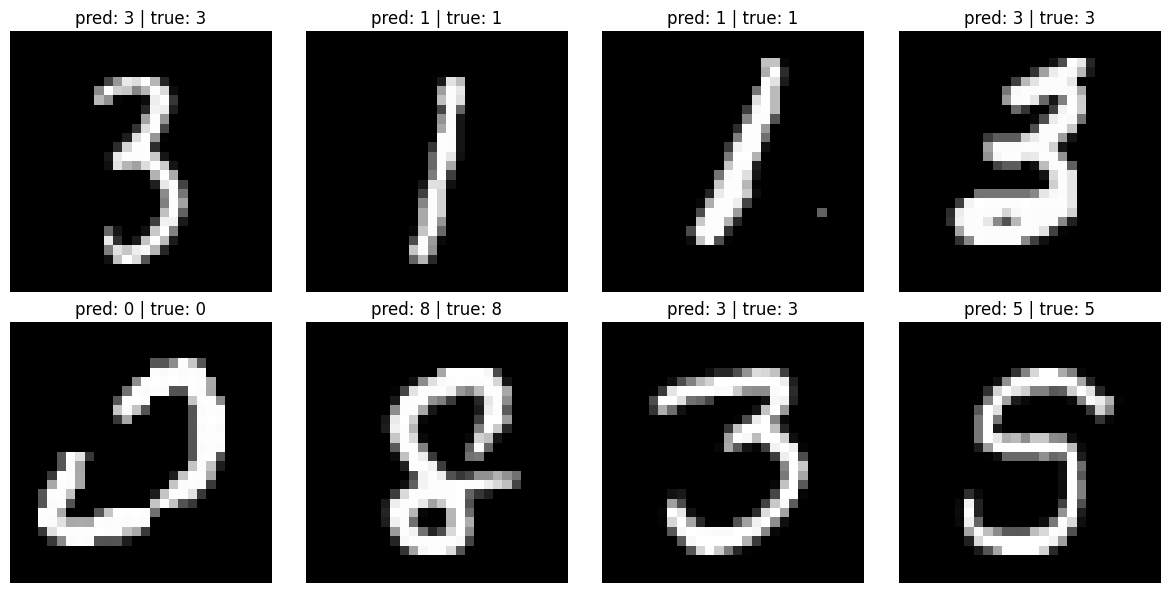

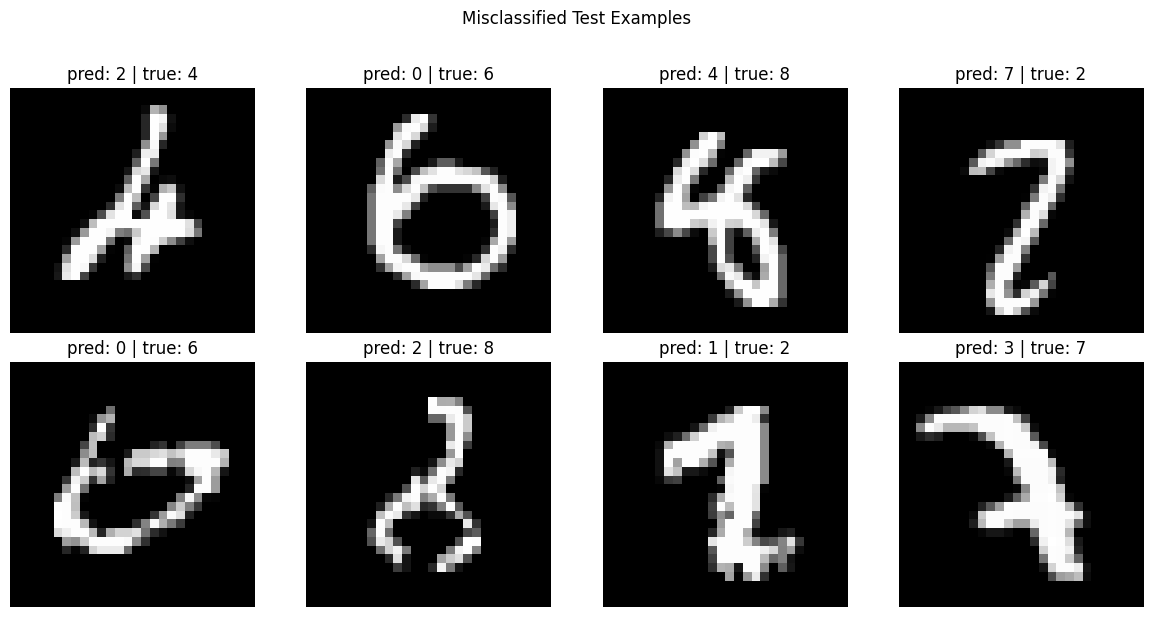

In [10]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Train accuracy")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.0)
axes[1].legend()
plt.tight_layout()
plt.show()

sample_loader = DataLoader(test_loader.dataset, batch_size=8, shuffle=True)

model.eval()
confusion = torch.zeros(10, 10, dtype=torch.int64)
confidences = []
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        logits = model(batch_images.to(device))
        probs = torch.softmax(logits, dim=1).cpu()
        preds = probs.argmax(dim=1)
        confidences.extend(probs.max(dim=1).values.tolist())

        for true_label, pred_label in zip(batch_labels, preds):
            confusion[true_label.long(), pred_label.long()] += 1

        wrong_mask = preds.ne(batch_labels)
        if wrong_mask.any() and len(misclassified_images) < 8:
            remaining = 8 - len(misclassified_images)
            misclassified_images.extend(batch_images[wrong_mask][:remaining])
            misclassified_labels.extend(batch_labels[wrong_mask][:remaining].tolist())
            misclassified_preds.extend(preds[wrong_mask][:remaining].tolist())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(confusion.numpy(), cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
plt.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(confidences, bins=20, color="tab:blue", edgecolor="black")
ax.set_title("Prediction Confidence Distribution")
ax.set_xlabel("Max predicted probability")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

trained_filters = model.conv1.weight.detach().cpu()
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for ax, filt in zip(axes[0], initial_conv1_filters[:8]):
    ax.imshow(filt.squeeze(), cmap="gray")
    ax.axis("off")
for ax, filt in zip(axes[1], trained_filters[:8]):
    ax.imshow(filt.squeeze(), cmap="gray")
    ax.axis("off")
fig.text(0.02, 0.72, "Init", va="center", rotation=90)
fig.text(0.02, 0.28, "Trained", va="center", rotation=90)
fig.suptitle("First 8 conv1 filters before and after training", y=1.04)
plt.tight_layout()
plt.show()

sample_images, sample_labels = next(iter(sample_loader))
sample_image = sample_images[:1].to(device)

with torch.no_grad():
    sample_logits, sample_activations = model.forward_features(sample_image)
    sample_probs = torch.softmax(sample_logits, dim=1).squeeze(0).cpu()
    batch_logits = model(sample_images.to(device))
    batch_preds = batch_logits.argmax(dim=1).cpu()

print("Single-image shape trace:")
print("  input:", tuple(sample_image.shape))
print("  after conv1 + relu:", tuple(sample_activations["relu1"].shape))
print("  after conv2 + relu:", tuple(sample_activations["relu2"].shape))
print("  after max pool:", tuple(sample_activations["pool"].shape))
print("  after flatten:", tuple(sample_activations["flatten"].shape))
print("  logits:", tuple(sample_logits.shape))
print("  probabilities sum to:", f"{sample_probs.sum().item():.3f}")

top_probs, top_labels = sample_probs.topk(3)
print("Top predicted classes for the sample image:")
for label, prob in zip(top_labels.tolist(), top_probs.tolist()):
    print(f"  class {label}: {prob:.3f}")

conv1_relu = sample_activations["relu1"].cpu().squeeze(0)
conv2_relu = sample_activations["relu2"].cpu().squeeze(0)
top_conv1_idx = conv1_relu.mean(dim=(1, 2)).topk(8).indices.tolist()
top_conv2_idx = conv2_relu.mean(dim=(1, 2)).topk(8).indices.tolist()

display_images = sample_images * 0.3081 + 0.1307
display_image = sample_image.cpu() * 0.3081 + 0.1307

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flat
axes[0].imshow(display_image.squeeze(), cmap="gray")
axes[0].set_title(f"Input digit: {sample_labels[0].item()}")
axes[0].axis("off")
for ax, channel_idx in zip(list(axes)[1:], top_conv1_idx):
    ax.imshow(conv1_relu[channel_idx], cmap="magma")
    ax.set_title(f"ch {channel_idx}")
    ax.axis("off")
fig.suptitle("Top-activating conv1 feature maps", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flat
axes[0].imshow(display_image.squeeze(), cmap="gray")
axes[0].set_title(f"Input digit: {sample_labels[0].item()}")
axes[0].axis("off")
for ax, channel_idx in zip(list(axes)[1:], top_conv2_idx):
    ax.imshow(conv2_relu[channel_idx], cmap="magma")
    ax.set_title(f"ch {channel_idx}")
    ax.axis("off")
fig.suptitle("Top-activating conv2 feature maps", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(10), sample_logits.squeeze(0).cpu().tolist(), color="tab:orange")
axes[0].set_title("Logits for one sample")
axes[0].set_xlabel("Digit class")
axes[0].set_ylabel("Logit value")
axes[0].set_xticks(range(10))

axes[1].bar(range(10), sample_probs.tolist(), color="tab:blue")
axes[1].set_title("Softmax probabilities for one sample")
axes[1].set_xlabel("Digit class")
axes[1].set_ylabel("Probability")
axes[1].set_xticks(range(10))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, pred, label in zip(axes.flat, display_images, batch_preds, sample_labels):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"pred: {pred.item()} | true: {label.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

if misclassified_images:
    misclassified_tensor = torch.stack(misclassified_images) * 0.3081 + 0.1307
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, image, pred, label in zip(axes.flat, misclassified_tensor, misclassified_preds, misclassified_labels):
        ax.imshow(image.squeeze(), cmap="gray")
        ax.set_title(f"pred: {pred} | true: {label}")
        ax.axis("off")
    fig.suptitle("Misclassified Test Examples", y=1.02)
    plt.tight_layout()
    plt.show()
